### Configuración GPU e Importaciones

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sysconfig import get_paths
import ctypes
import os
import gc

site_packages = Path(get_paths()['purelib'])
cuda_lib_dirs = [
    site_packages / 'nvidia' / 'cuda_runtime' / 'lib',
    site_packages / 'nvidia' / 'cuda_nvrtc' / 'lib',
    site_packages / 'nvidia' / 'cublas' / 'lib',
    site_packages / 'nvidia' / 'cufft' / 'lib',
    site_packages / 'nvidia' / 'curand' / 'lib',
    site_packages / 'nvidia' / 'cusolver' / 'lib',
    site_packages / 'nvidia' / 'cusparse' / 'lib',
    site_packages / 'nvidia' / 'cudnn' / 'lib',
    site_packages / 'nvidia' / 'cuda_cupti' / 'lib',
    site_packages / 'nvidia' / 'nccl' / 'lib',
    site_packages / 'nvidia' / 'nvjitlink' / 'lib',
]

loaded_cuda_libs = 0
for lib_dir in cuda_lib_dirs:
    if lib_dir.exists():
        for lib_path in sorted(lib_dir.glob('*.so*')):
            ctypes.CDLL(str(lib_path), mode=ctypes.RTLD_GLOBAL)
            loaded_cuda_libs += 1

existing_ld = os.environ.get('LD_LIBRARY_PATH', '')
cuda_ld_paths = [str(path) for path in cuda_lib_dirs if path.exists()]
if existing_ld:
    cuda_ld_paths.append(existing_ld)
os.environ['LD_LIBRARY_PATH'] = ':'.join(cuda_ld_paths)
print(f'Librerías CUDA cargadas: {loaded_cuda_libs}')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print('TensorFlow:', tf.__version__)
print('GPUs detectadas:', gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Crecimiento de memoria habilitado.")
    except RuntimeError as e:
        print(e)

I0000 00:00:1783783843.402823   11667 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Librerías CUDA cargadas: 31
TensorFlow: 2.21.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Crecimiento de memoria habilitado.


### Carga y Preprocesamiento de Datos

In [2]:
# Cargar dataset
print("Cargando dataset...")
df = pd.read_csv('../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

# Renombrar variable objetivo
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Eliminar ID
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} características")

# Separar variables
X = df.drop('default', axis=1)
y = df['default']

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Distribución clases - Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")

Cargando dataset...
Dataset cargado: 30000 registros, 24 características
Train: (24000, 23), Test: (6000, 23)
Distribución clases - Train: [18691  5309], Test: [4673 1327]


### Implementación de Grey Wolf Optimizer (GWO)

In [3]:
class GreyWolfOptimizerOptimized:
    """
    GWO Optimizado para mínimo consumo de memoria RAM
    """
    def __init__(self, n_wolves=15, max_iter=20, dim=4):
        self.n_wolves = n_wolves
        self.max_iter = max_iter
        self.dim = dim
        
        # Inicializar posiciones con valores válidos
        self.positions = np.zeros((n_wolves, dim), dtype=np.float32)
        for i in range(n_wolves):
            self.positions[i, 0] = np.random.uniform(0.001, 0.01)    # learning_rate
            self.positions[i, 1] = np.random.uniform(0.1, 0.5)       # dropout_rate
            self.positions[i, 2] = np.random.uniform(16, 64)         # neurons1
            self.positions[i, 3] = np.random.uniform(8, 32)          # neurons2
        
        self.fitness = np.full(n_wolves, np.inf, dtype=np.float32)
        
        self.alpha_pos = np.zeros(dim, dtype=np.float32)
        self.alpha_score = np.inf
        self.beta_pos = np.zeros(dim, dtype=np.float32)
        self.beta_score = np.inf
        self.delta_pos = np.zeros(dim, dtype=np.float32)
        self.delta_score = np.inf
        
        self.history = []
        
    def create_mlp(self, params, input_dim):
        """Crear MLP con hiperparámetros dados"""
        lr = max(float(params[0]), 1e-6)
        dropout = np.clip(float(params[1]), 0.05, 0.7)
        n1 = max(int(params[2]), 8)
        n2 = max(int(params[3]), 4)
        
        model = Sequential([
            Dense(n1, activation='relu', input_dim=input_dim),
            BatchNormalization(),
            Dropout(dropout),
            Dense(n2, activation='relu'),
            BatchNormalization(),
            Dropout(dropout),
            Dense(1, activation='sigmoid')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )
        
        return model
    
    def evaluate_fitness(self, params, X_train, y_train, X_val, y_val):
        """
        Evaluar fitness con limpieza agresiva de memoria
        """
        model = None
        history = None
        fitness = np.inf
        
        try:
            # Crear modelo
            model = self.create_mlp(params, X_train.shape[1])
            
            # Entrenar con pocas épocas para evaluación rápida
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=8,  # Reducido para velocidad
                batch_size=256,
                verbose=0,
                callbacks=[
                    EarlyStopping(
                        monitor='val_auc', 
                        mode='max', 
                        patience=2, 
                        restore_best_weights=True
                    )
                ]
            )
            
            # Obtener AUC de validación
            if 'val_auc' in history.history and len(history.history['val_auc']) > 0:
                val_auc = max(history.history['val_auc'])
                
                if not np.isnan(val_auc) and not np.isinf(val_auc):
                    fitness = 1.0 - val_auc
            
        except Exception as e:
            print(f"Error en evaluación: {e}")
            fitness = np.inf
        
        finally:
            # 🔥 LIMPIEZA AGRESIVA DE MEMORIA
            if model is not None:
                del model
            
            if history is not None:
                del history
            
            # Limpiar sesión de Keras (CRÍTICO)
            tf.keras.backend.clear_session()
            
            # Forzar garbage collection
            gc.collect()
        
        return fitness
    
    def optimize(self, X_train, y_train, X_val, y_val):
        """Ejecutar optimización GWO con optimización de memoria"""
        print(f"\n🐺 Iniciando GWO Optimizado: {self.n_wolves} lobos, {self.max_iter} iteraciones")
        print(f"Usando {X_train.shape[0]} muestras de entrenamiento")
        
        # Evaluar población inicial
        print("Evaluando población inicial...")
        for i in range(self.n_wolves):
            self.fitness[i] = self.evaluate_fitness(
                self.positions[i], X_train, y_train, X_val, y_val
            )
            if i % 5 == 0:
                print(f"  Lobo {i+1}/{self.n_wolves}: fitness = {self.fitness[i]:.4f}")
        
        # Actualizar alpha, beta, delta iniciales
        sorted_indices = np.argsort(self.fitness)
        self.alpha_score = self.fitness[sorted_indices[0]]
        self.alpha_pos = self.positions[sorted_indices[0]].copy()
        self.beta_score = self.fitness[sorted_indices[1]]
        self.beta_pos = self.positions[sorted_indices[1]].copy()
        self.delta_score = self.fitness[sorted_indices[2]]
        self.delta_pos = self.positions[sorted_indices[2]].copy()
        
        print(f"\n✅ Mejor fitness inicial: {self.alpha_score:.4f} (AUC: {1-self.alpha_score:.4f})")
        
        # Loop principal de optimización
        for iteration in range(self.max_iter):
            a = 2 * (1 - (iteration / self.max_iter) ** 2)
            
            # Actualizar posiciones de los lobos
            for i in range(self.n_wolves):
                for j in range(self.dim):
                    r1, r2 = np.random.random(), np.random.random()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * self.alpha_pos[j] - self.positions[i, j])
                    X1 = self.alpha_pos[j] - A1 * D_alpha
                    
                    r1, r2 = np.random.random(), np.random.random()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * self.beta_pos[j] - self.positions[i, j])
                    X2 = self.beta_pos[j] - A2 * D_beta
                    
                    r1, r2 = np.random.random(), np.random.random()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * self.delta_pos[j] - self.positions[i, j])
                    X3 = self.delta_pos[j] - A3 * D_delta
                    
                    self.positions[i, j] = (X1 + X2 + X3) / 3
            
            # Mantener límites válidos
            self.positions[:, 0] = np.clip(self.positions[:, 0], 0.0001, 0.01)
            self.positions[:, 1] = np.clip(self.positions[:, 1], 0.05, 0.7)
            self.positions[:, 2] = np.clip(self.positions[:, 2], 8, 128)
            self.positions[:, 3] = np.clip(self.positions[:, 3], 4, 64)
            
            # Evaluar nueva población
            for i in range(self.n_wolves):
                self.fitness[i] = self.evaluate_fitness(
                    self.positions[i], X_train, y_train, X_val, y_val
                )
            
            # Actualizar alpha, beta, delta
            for i in range(self.n_wolves):
                if self.fitness[i] < self.alpha_score:
                    self.delta_score = self.beta_score
                    self.delta_pos = self.beta_pos.copy()
                    self.beta_score = self.alpha_score
                    self.beta_pos = self.alpha_pos.copy()
                    self.alpha_score = self.fitness[i]
                    self.alpha_pos = self.positions[i].copy()
                elif self.fitness[i] < self.beta_score:
                    self.delta_score = self.beta_score
                    self.delta_pos = self.beta_pos.copy()
                    self.beta_score = self.fitness[i]
                    self.beta_pos = self.positions[i].copy()
                elif self.fitness[i] < self.delta_score:
                    self.delta_score = self.fitness[i]
                    self.delta_pos = self.positions[i].copy()
            
            # Guardar historial (cada 5 iteraciones para ahorrar memoria)
            if iteration % 5 == 0:
                self.history.append({
                    'iteration': iteration,
                    'alpha_score': float(self.alpha_score),
                    'alpha_pos': self.alpha_pos.copy()
                })
                print(f"Iter {iteration:3d} | Alpha AUC: {1-self.alpha_score:.4f} | "
                      f"LR: {self.alpha_pos[0]:.5f}, DO: {self.alpha_pos[1]:.3f}, "
                      f"N1: {int(self.alpha_pos[2])}, N2: {int(self.alpha_pos[3])}")
                
                # Forzar limpieza cada 5 iteraciones
                gc.collect()
        
        # Verificar resultado final
        if np.isinf(self.alpha_score):
            print("\n⚠️ ADVERTENCIA: No se encontró solución válida. Usando valores por defecto.")
            self.alpha_pos = np.array([0.001, 0.2, 32, 16], dtype=np.float32)
            self.alpha_score = 0.3
        
        print(f"\n✅ Optimización completada!")
        print(f"Mejor AUC: {1-self.alpha_score:.4f}")
        print(f"Mejor configuración: LR={self.alpha_pos[0]:.5f}, Dropout={self.alpha_pos[1]:.3f}, "
              f"N1={int(self.alpha_pos[2])}, N2={int(self.alpha_pos[3])}\n")
        
        # Limpieza final
        gc.collect()
        
        return self.alpha_pos, self.alpha_score

### Ejecutar Optimización GWO

In [4]:
# Dividir datos para GWO
X_train_gwo, X_val, y_train_gwo, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Convertir a float32 para ahorrar memoria
X_train_gwo = X_train_gwo.astype(np.float32)
X_val = X_val.astype(np.float32)
y_train_gwo = y_train_gwo.astype(np.float32)
y_val = y_val.astype(np.float32)

# Inicializar GWO optimizado
gwo = GreyWolfOptimizerOptimized(
    n_wolves=15,      # Reducido de 20
    max_iter=20,      # Reducido de 30
    dim=4
)

# Ejecutar optimización
best_params, best_fitness = gwo.optimize(
    X_train_gwo, y_train_gwo, X_val, y_val
)

best_lr = float(best_params[0])
best_dropout = float(best_params[1])
best_n1 = int(best_params[2])
best_n2 = int(best_params[3])

print("="*60)
print("🏆 RESULTADOS GWO - MEJORES HIPERPARÁMETROS")
print("="*60)
print(f"Learning Rate:  {best_lr:.6f}")
print(f"Dropout Rate:   {best_dropout:.3f}")
print(f"Neuronas Capa1: {best_n1}")
print(f"Neuronas Capa2: {best_n2}")
print(f"Val AUC GWO:    {1-best_fitness:.4f}")
print("="*60)


🐺 Iniciando GWO Optimizado: 15 lobos, 20 iteraciones
Usando 19200 muestras de entrenamiento
Evaluando población inicial...


I0000 00:00:1783783858.891305   11667 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2128 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1783783860.851106   12062 service.cc:153] XLA service 0x7f9b24037e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783783860.851124   12062 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783783860.897939   12062 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783783861.179388   12062 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783783861.241455   12062 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2491__.25
I0000 00:00:1783783861.766484   12062 dot_search_s

  Lobo 1/15: fitness = 0.2282


I0000 00:00:1783783870.137452   12062 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10354__.25
I0000 00:00:1783783870.191776   12062 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783783879.043129   12061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17574__.25
I0000 00:00:1783783885.792042   12062 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23564__.25
I0000 00:00:1783783892.649146   12064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28939__.25
I0000 00:00:1783783900.505898   12062 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36774__.25


  Lobo 6/15: fitness = 0.2348


...

Iter  10 | Alpha AUC: 0.7747 | LR: 0.01000, DO: 0.154, N1: 39, N2: 64


I0000 00:00:1783785390.500726   12064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1310573__.25
I0000 00:00:1783785390.716812   12064 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783785400.387582   12061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1318416__.25
I0000 00:00:1783785400.561887   12061 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783785401.257262  129953 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 60 bytes spill store

Iter  15 | Alpha AUC: 0.7747 | LR: 0.01000, DO: 0.154, N1: 39, N2: 64


I0000 00:00:1783786257.711818   12060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1834266__.25
I0000 00:00:1783786257.879554   12060 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783786258.553978  177432 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 52 bytes spill stores, 52 bytes spill loads

I0000 00:00:1783786258.602471   12060 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783786261.915372   12062 dot_search_space.cc:240] All configs were filtered out because no


✅ Optimización completada!
Mejor AUC: 0.7747
Mejor configuración: LR=0.01000, Dropout=0.154, N1=39, N2=64

🏆 RESULTADOS GWO - MEJORES HIPERPARÁMETROS
Learning Rate:  0.010000
Dropout Rate:   0.154
Neuronas Capa1: 39
Neuronas Capa2: 64
Val AUC GWO:    0.7747


### Entrenar Modelo Final con Mejores Parámetros

In [5]:
# Crear modelo final con mejores hiperparámetros
print("\n🚀 Entrenando modelo final con hiperparámetros optimizados...")

final_model = Sequential([
    Dense(best_n1, activation='relu', input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    Dropout(best_dropout),
    Dense(best_n2, activation='relu'),
    BatchNormalization(),
    Dropout(best_dropout),
    Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer=Adam(learning_rate=best_lr),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Calcular class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# Entrenar
history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=256,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ Modelo final entrenado exitosamente!")


🚀 Entrenando modelo final con hiperparámetros optimizados...
Epoch 1/500


I0000 00:00:1783787054.177823   12064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2253892__.25


60/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7083 - auc: 0.7245 - loss: 0.6216

I0000 00:00:1783787055.940355   12064 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_maximum_reduce_fusion_1', 4 bytes spill stores, 8 bytes spill loads



75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7158 - auc: 0.7310 - loss: 0.6134 - val_accuracy: 0.7231 - val_auc: 0.7457 - val_loss: 0.6188 - learning_rate: 0.0100
Epoch 2/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7456 - auc: 0.7655 - loss: 0.5739 - val_accuracy: 0.7138 - val_auc: 0.7681 - val_loss: 0.6014 - learning_rate: 0.0100
Epoch 3/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7473 - auc: 0.7665 - loss: 0.5709 - val_accuracy: 0.7613 - val_auc: 0.7674 - val_loss: 0.5728 - learning_rate: 0.0100
Epoch 4/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7548 - auc: 0.7723 - loss: 0.5663 - val_accuracy: 0.7806 - val_auc: 0.7743 - val_loss: 0.5481 - learning_rate: 0.0100
Epoch 5/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7514 - auc: 0.7727 - loss: 0.5652 - val_accuracy: 0.7592 - val_auc: 0.7681 - val_loss: 0.5679 - learning_rate: 0.0100
Epoch 6/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7549 - auc: 0.7768 - loss: 0.56

### Evaluación y Métricas


📊 EVALUACIÓN DEL MODELO HÍBRIDO GWO-MLP
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy:  0.7517
Precision: 0.4540
Recall:    0.6059
F1-Score:  0.5190
ROC-AUC:   0.7721


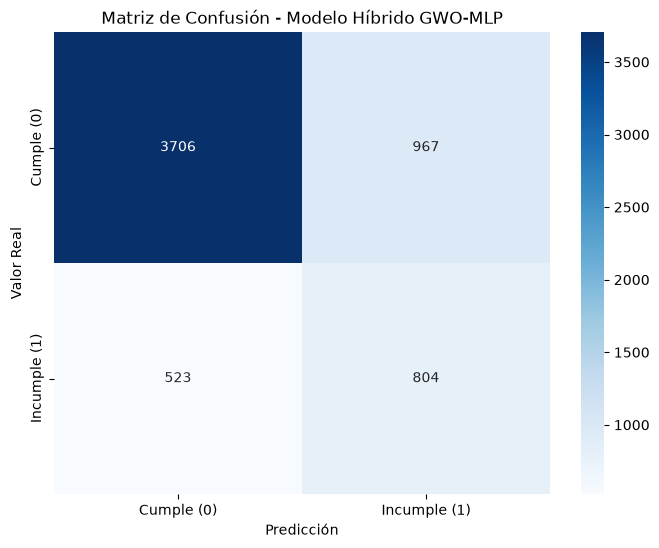


TP: 804 | FP: 967
FN: 523 | TN: 3706


In [6]:
# Evaluar en test set
print("\n📊 EVALUACIÓN DEL MODELO HÍBRIDO GWO-MLP")
print("="*60)

y_pred_prob = final_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("="*60)

# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cumple (0)', 'Incumple (1)'],
            yticklabels=['Cumple (0)', 'Incumple (1)'])
plt.title('Matriz de Confusión - Modelo Híbrido GWO-MLP')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

print(f"\nTP: {cm[1,1]} | FP: {cm[0,1]}")
print(f"FN: {cm[1,0]} | TN: {cm[0,0]}")

### Visualización de Convergencia GWO

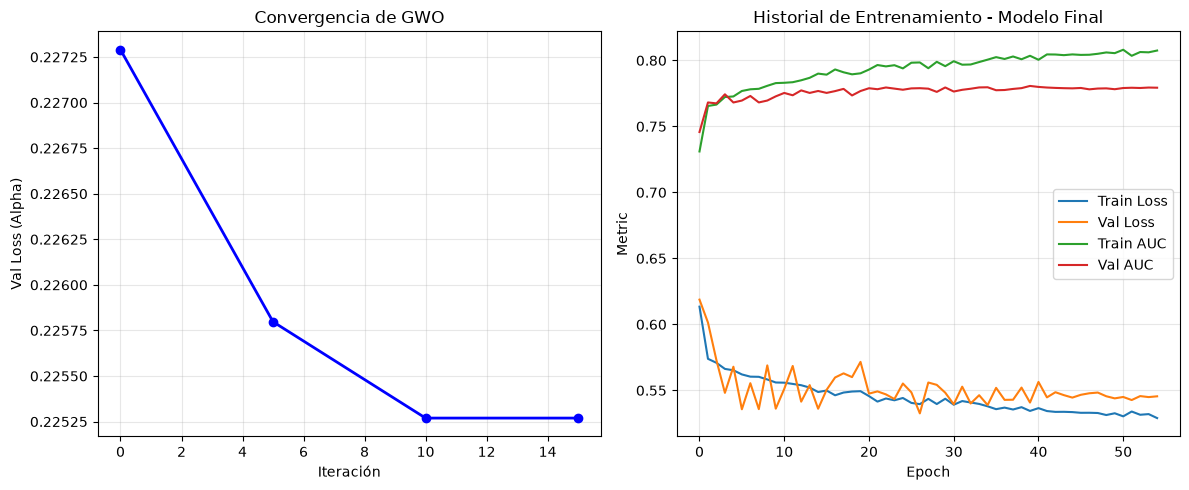

In [7]:
# Visualizar convergencia de GWO
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
iterations = [h['iteration'] for h in gwo.history]
scores = [h['alpha_score'] for h in gwo.history]
plt.plot(iterations, scores, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Iteración')
plt.ylabel('Val Loss (Alpha)')
plt.title('Convergencia de GWO')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('Historial de Entrenamiento - Modelo Final')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()